In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../../data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("TELCO CUSTOMER CHURN DATASET")
print()
print(f"Shape         : {df.shape}")
print(f"Total customers: {len(df):,}")
print()
print("Columns:")
for col in df.columns:
    print(f"  {col:<30}: {df[col].dtype} | unique={df[col].nunique()}")

TELCO CUSTOMER CHURN DATASET

Shape         : (7043, 21)
Total customers: 7,043

Columns:
  customerID                    : object | unique=7043
  gender                        : object | unique=2
  SeniorCitizen                 : int64 | unique=2
  Partner                       : object | unique=2
  Dependents                    : object | unique=2
  tenure                        : int64 | unique=73
  PhoneService                  : object | unique=2
  MultipleLines                 : object | unique=3
  InternetService               : object | unique=3
  OnlineSecurity                : object | unique=3
  OnlineBackup                  : object | unique=3
  DeviceProtection              : object | unique=3
  TechSupport                   : object | unique=3
  StreamingTV                   : object | unique=3
  StreamingMovies               : object | unique=3
  Contract                      : object | unique=3
  PaperlessBilling              : object | unique=2
  PaymentMethod         

CHURN ANALYSIS

Churned customers  : 1,869 (26.54%)
Retained customers : 5,174 (73.46%)
Churn rate         : 26.54%

Missing values:
  No missing values

TotalCharges dtype: object
TotalCharges converted to numeric
TotalCharges range: 18.80 to 8684.80


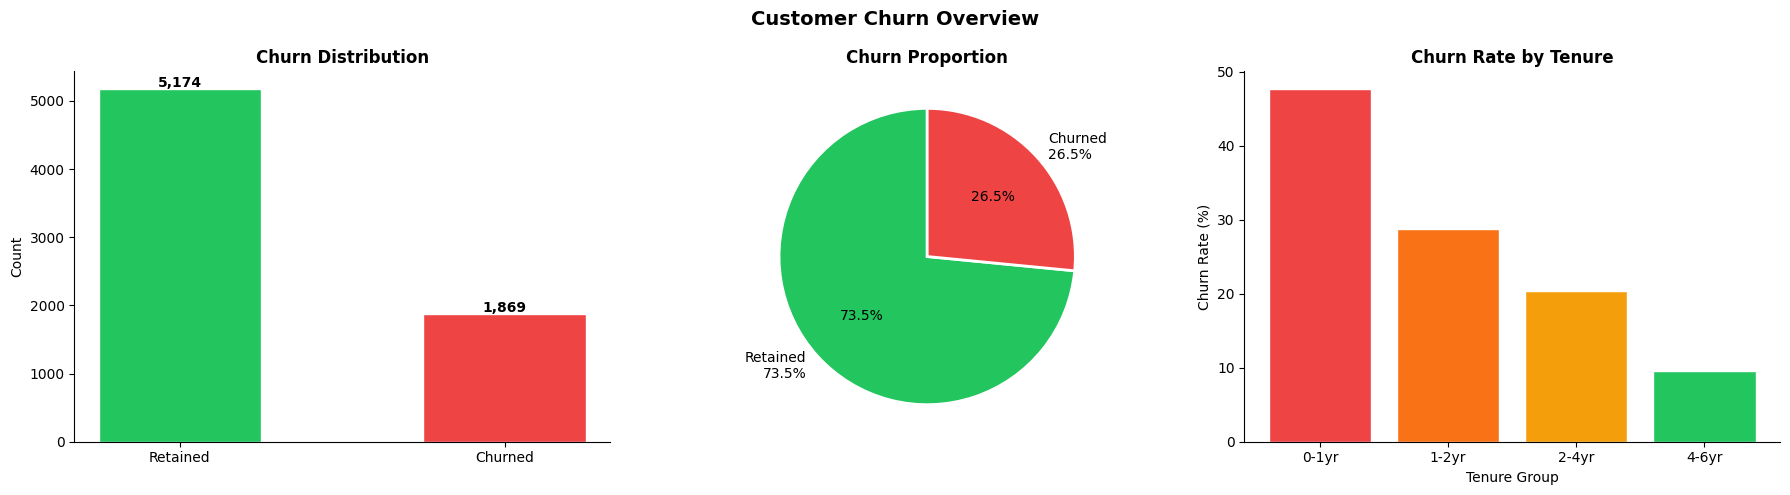

In [2]:
print("CHURN ANALYSIS")
print()

df["Churn_Binary"] = (df["Churn"] == "Yes").astype(int)

churned = df["Churn_Binary"].sum()
stayed = (df["Churn_Binary"] == 0).sum()
total = len(df)

print(f"Churned customers  : {churned:,} ({churned/total*100:.2f}%)")
print(f"Retained customers : {stayed:,} ({stayed/total*100:.2f}%)")
print(f"Churn rate         : {churned/total*100:.2f}%")
print()

print("Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values")
else:
    print(missing[missing > 0])

print()
print("TotalCharges dtype:", df["TotalCharges"].dtype)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("TotalCharges converted to numeric")
print(f"TotalCharges range: {df['TotalCharges'].min():.2f} to {df['TotalCharges'].max():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(["Retained", "Churned"], [stayed, churned],
            color=["#22c55e", "#ef4444"], edgecolor="white", width=0.5)
axes[0].set_title("Churn Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate([stayed, churned]):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie([stayed, churned], labels=["Retained\n73.5%", "Churned\n26.5%"],
            colors=["#22c55e", "#ef4444"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Churn Proportion", fontweight="bold")

churn_by_tenure = df.groupby(pd.cut(df["tenure"], bins=[0,12,24,48,72],
                                     labels=["0-1yr","1-2yr","2-4yr","4-6yr"]))["Churn_Binary"].mean() * 100
axes[2].bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
            color=["#ef4444","#f97316","#f59e0b","#22c55e"], edgecolor="white")
axes[2].set_title("Churn Rate by Tenure", fontweight="bold")
axes[2].set_xlabel("Tenure Group")
axes[2].set_ylabel("Churn Rate (%)")

plt.suptitle("Customer Churn Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/customer_churn/churn_overview.png", dpi=150, bbox_inches="tight")
plt.show()

FEATURE ANALYSIS

Numeric features — churn vs retained:
  tenure              : churned=17.98  retained=37.57
  MonthlyCharges      : churned=74.44  retained=61.27
  TotalCharges        : churned=1531.80  retained=2552.88

Top categorical signals:
  gender              : highest churn in 'Female' at 26.9%
  SeniorCitizen       : highest churn in '1' at 41.7%
  Partner             : highest churn in 'No' at 33.0%
  Dependents          : highest churn in 'No' at 31.3%
  PhoneService        : highest churn in 'Yes' at 26.7%
  MultipleLines       : highest churn in 'Yes' at 28.6%
  InternetService     : highest churn in 'Fiber optic' at 41.9%
  OnlineSecurity      : highest churn in 'No' at 41.8%


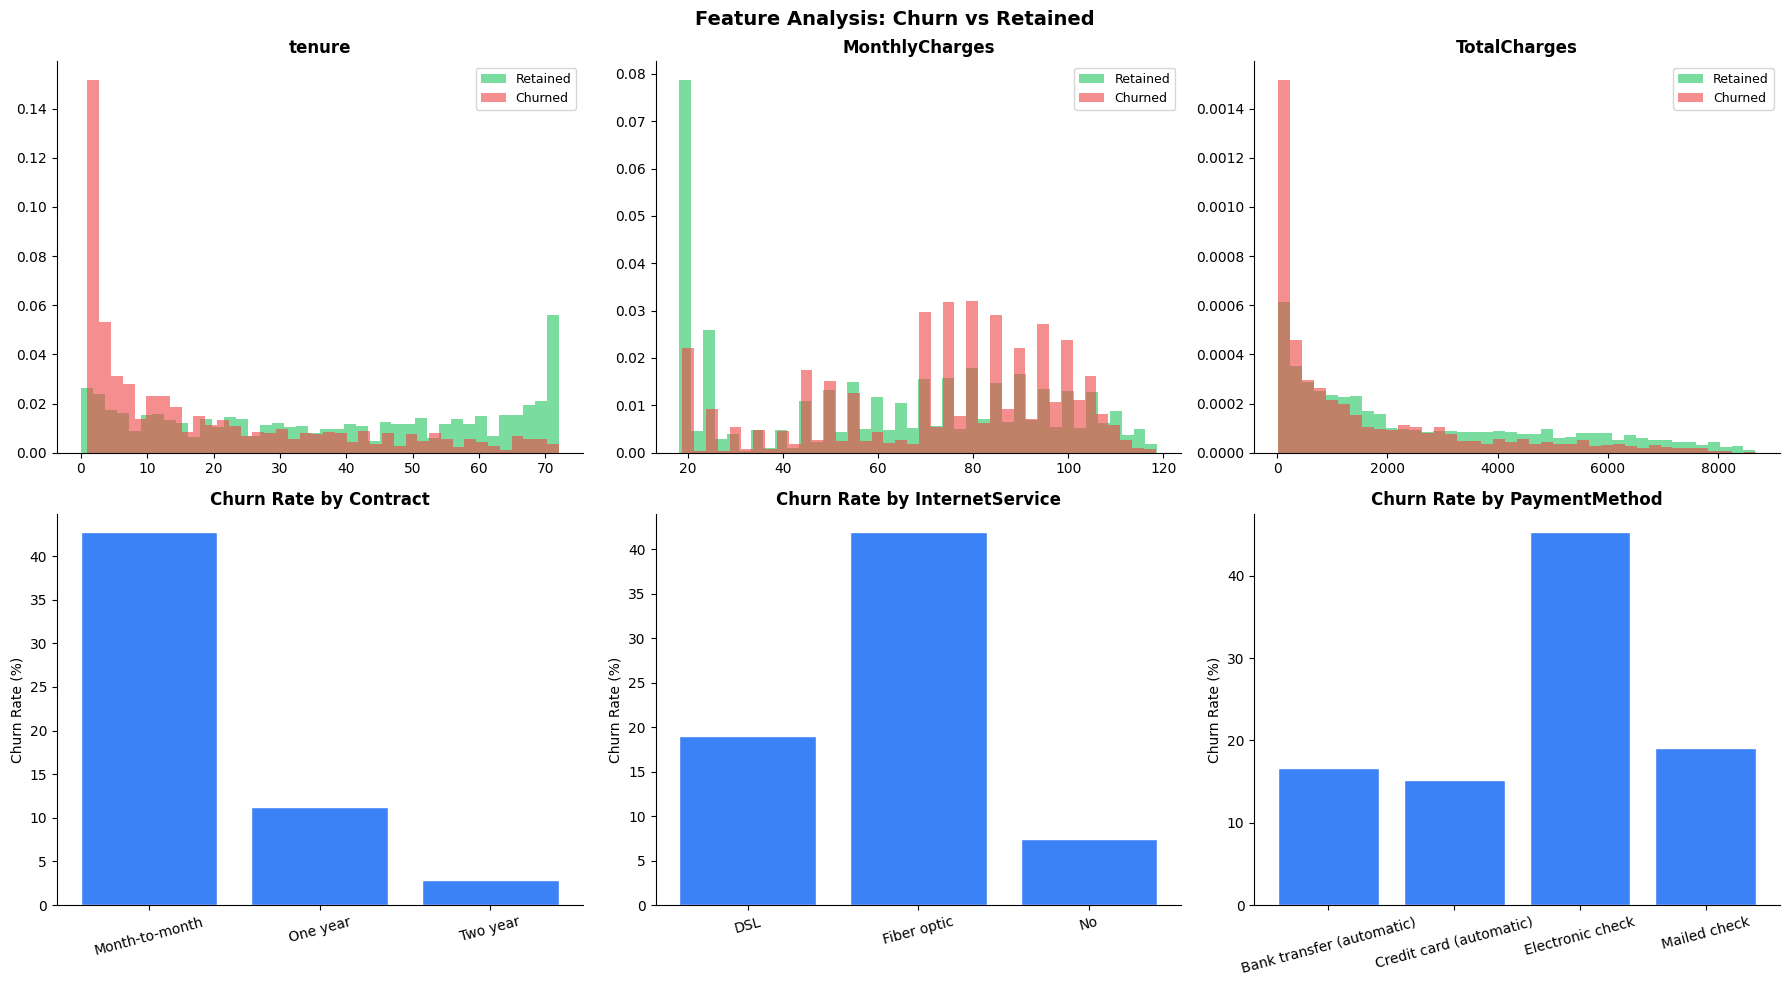

In [3]:
# Feature Analysis
print("FEATURE ANALYSIS")
print()

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = ["gender", "SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "MultipleLines", "InternetService",
                    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                    "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaperlessBilling", "PaymentMethod"]

print("Numeric features — churn vs retained:")
for col in numeric_cols:
    churn_mean = df[df["Churn_Binary"]==1][col].mean()
    retain_mean = df[df["Churn_Binary"]==0][col].mean()
    print(f"  {col:<20}: churned={churn_mean:.2f}  retained={retain_mean:.2f}")

print()
print("Top categorical signals:")
for col in categorical_cols[:8]:
    churn_rates = df.groupby(col)["Churn_Binary"].mean() * 100
    max_rate = churn_rates.max()
    max_cat = churn_rates.idxmax()
    print(f"  {col:<20}: highest churn in '{max_cat}' at {max_rate:.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    churned_vals = df[df["Churn_Binary"]==1][col]
    retained_vals = df[df["Churn_Binary"]==0][col]
    axes[i].hist(retained_vals, bins=40, color="#22c55e", alpha=0.6, label="Retained", density=True)
    axes[i].hist(churned_vals, bins=40, color="#ef4444", alpha=0.6, label="Churned", density=True)
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=9)

for i, col in enumerate(["Contract", "InternetService", "PaymentMethod"]):
    ax = axes[i+3]
    churn_rates = df.groupby(col)["Churn_Binary"].mean() * 100
    ax.bar(churn_rates.index, churn_rates.values, color="#3b82f6", edgecolor="white")
    ax.set_title(f"Churn Rate by {col}", fontweight="bold")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Feature Analysis: Churn vs Retained", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/customer_churn/feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Correlation and Business Analysis
print("CORRELATION AND BUSINESS ANALYSIS")
print()

print("Contract type impact (most important business lever):")
contract_analysis = df.groupby("Contract")["Churn_Binary"].agg(["mean","count","sum"])
contract_analysis["churn_rate_%"] = contract_analysis["mean"] * 100
print(contract_analysis[["count","sum","churn_rate_%"]].rename(
    columns={"count":"customers","sum":"churned"}))

print()
print("Internet Service impact:")
internet_analysis = df.groupby("InternetService")["Churn_Binary"].agg(["mean","count"])
internet_analysis["churn_rate_%"] = internet_analysis["mean"] * 100
print(internet_analysis[["count","churn_rate_%"]])

print()
print("Revenue impact of churn:")
churned_revenue = df[df["Churn_Binary"]==1]["MonthlyCharges"].sum()
total_revenue = df["MonthlyCharges"].sum()
print(f"  Monthly revenue at risk  : ${churned_revenue:,.2f}")
print(f"  Total monthly revenue    : ${total_revenue:,.2f}")
print(f"  Revenue churn rate       : {churned_revenue/total_revenue*100:.2f}%")

print()
print("Senior citizens:")
senior = df[df["SeniorCitizen"]==1]["Churn_Binary"].mean() * 100
non_senior = df[df["SeniorCitizen"]==0]["Churn_Binary"].mean() * 100
print(f"  Senior citizen churn rate    : {senior:.2f}%")
print(f"  Non-senior citizen churn rate: {non_senior:.2f}%")

correlation = df[["tenure","MonthlyCharges","TotalCharges","SeniorCitizen","Churn_Binary"]].corr()
print()
print("Numeric correlations with churn:")
print(correlation["Churn_Binary"].drop("Churn_Binary").round(4))

CORRELATION AND BUSINESS ANALYSIS

Contract type impact (most important business lever):
                customers  churned  churn_rate_%
Contract                                        
Month-to-month       3875     1655       42.7097
One year             1473      166       11.2695
Two year             1695       48        2.8319

Internet Service impact:
                 count  churn_rate_%
InternetService                     
DSL               2421       18.9591
Fiber optic       3096       41.8928
No                1526        7.4050

Revenue impact of churn:
  Monthly revenue at risk  : $139,130.85
  Total monthly revenue    : $456,116.60
  Revenue churn rate       : 30.50%

Senior citizens:
  Senior citizen churn rate    : 41.68%
  Non-senior citizen churn rate: 23.61%

Numeric correlations with churn:
tenure           -0.3522
MonthlyCharges    0.1934
TotalCharges     -0.1990
SeniorCitizen     0.1509
Name: Churn_Binary, dtype: float64


In [6]:
# Save and Key Findings
import json
import os

print("KEY FINDINGS")
print()
print(f"1. Churn rate       : 26.5% — significant but manageable")
print(f"2. Tenure signal    : New customers (0-1yr) churn at {churn_by_tenure.iloc[0]:.1f}% — highest risk")
print(f"3. Contract impact  : Month-to-month contracts churn most — key intervention point")
print(f"4. Revenue at risk  : ${churned_revenue:,.0f}/month")
print(f"5. Internet service : Fiber optic customers churn more despite higher charges")
print(f"6. Dataset          : {len(df):,} customers, {len(df.columns)} features — clean, no major issues")
print()
print("Strategy:")
print("  Binary classification: will customer churn in next period?")
print("  Models: XGBoost + LightGBM + Logistic Regression")
print("  Business metric: Revenue saved by retaining at-risk customers")

os.makedirs("../../data/customer_churn", exist_ok=True)
df.to_csv("../../data/customer_churn/churn_cleaned.csv", index=False)

meta = {
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "target": "Churn_Binary",
    "n_customers": int(len(df)),
    "churn_rate": float(df["Churn_Binary"].mean()),
    "monthly_revenue_at_risk": float(churned_revenue)
}

with open("../../data/customer_churn/meta.json", "w") as f:
    json.dump(meta, f, indent=4)

print()


KEY FINDINGS

1. Churn rate       : 26.5% — significant but manageable
2. Tenure signal    : New customers (0-1yr) churn at 47.7% — highest risk
3. Contract impact  : Month-to-month contracts churn most — key intervention point
4. Revenue at risk  : $139,131/month
5. Internet service : Fiber optic customers churn more despite higher charges
6. Dataset          : 7,043 customers, 22 features — clean, no major issues

Strategy:
  Binary classification: will customer churn in next period?
  Models: XGBoost + LightGBM + Logistic Regression
  Business metric: Revenue saved by retaining at-risk customers

